# Descobrindo Segmentos de Uso de Dados de Assinantes com PROC FASTCLUS


## Resumo Executivo

Uma equipe de análise de telecomunicações deseja segmentar sua base de assinantes móveis pelo **consumo mensal de dados** sem impor limites arbitrários de GB. Usando o **PROC FASTCLUS** — o procedimento de agrupamento k-means de alto desempenho do SAS — deixamos que os próprios dados se particionem em classes de uso latentes (usuários leves, moderados e pesados). O FASTCLUS encontra o centro de cada segmento, atribui cada assinante ao mais próximo e informa o quão nitidamente os segmentos se separam — transformando uma única métrica de uso contínua em uma segmentação acionável e orientada por dados para o desenho de planos e marketing direcionado.


## Fontes de Dados

Todos os dados são gerados inline pela primeira etapa DATA — não há arquivos externos nem chamadas de rede. Os assinantes são extraídos de uma população de uso com três componentes, de modo que os segmentos recuperados possam ser validados contra uma verdade fundamental conhecida.

| Conjunto de Dados | Linhas | Variável | Tipo | Descrição |
|---------|------|----------|------|-------------|
| `subscribers` | 1.500 | `id` | Num | Identificador do assinante (1–1500) |
| `subscribers` | 1.500 | `data_gb` | Num | Dados móveis consumidos no mês, em GB (a métrica sobre a qual agrupamos) |
| `subscribers` | 1.500 | `segment_true` | Char | Segmento latente usado para *gerar* o valor (Leve ≈ N(3,1²) 50%, Moderado ≈ N(12,3²) 35%, Pesado ≈ N(35,8²) 15%); reservado apenas para validar os segmentos recuperados — um analista real não o observaria |


# Descobrindo Segmentos de Uso de Dados de Assinantes

Operadoras móveis raramente têm um rótulo limpo que diga *"este é um usuário pesado de dados."* O que elas têm é uma métrica contínua — gigabytes consumidos por mês — cuja distribuição é **multimodal**: agrupamentos de usuários leves, moderados e intensos se sobrepõem em um único eixo. A **análise de cluster** trata essa única coluna como um problema de geometria: localiza os centros de massa naturais na distribuição de uso e atribui cada assinante ao mais próximo, sem cortes escolhidos manualmente.

Neste notebook nós:

1. Geramos uma base sintética realista de assinantes cujo uso de dados vem de três segmentos ocultos.
2. Inspecionamos a distribuição marginal de uso para confirmar que é multimodal.
3. Padronizamos a métrica e executamos o **PROC FASTCLUS** para particionar os assinantes em três segmentos de uso.
4. Traçamos o perfil de cada segmento descoberto na escala original em GB e, então, validamos a recuperação contra a verdade conhecida.

O rótulo `segment_true` é gerado apenas para que possamos avaliar o agrupamento ao final — em produção ele não existiria.


In [1]:
/* Sintetizar uma base de assinantes a partir de três segmentos de uso latentes. */
/* Usuários leves dominam; uma pequena cauda de usuários pesados gera a maior parte da receita. */
DADOS subscribers;
   CHAMAR streaminit(20260531);
   COMPRIMENTO segment_true $8;
   RÓTULO id="ID do Assinante" data_gb="Consumo de Dados (GB)" segment_true="Segmento Real";
   FAZER id = 1 ATÉ 1500;
      u = rand('uniform');
      SE u < 0.50 ENTÃO FAZER;                 /* ~50% usuários leves      */
         segment_true = 'Leve';
         data_gb = rand('normal', 3.0, 1.0);
      FIM;
      SENÃO SE u < 0.85 ENTÃO FAZER;            /* ~35% usuários moderados  */
         segment_true = 'Moderado';
         data_gb = rand('normal', 12.0, 3.0);
      FIM;
      SENÃO FAZER;                             /* ~15% usuários pesados    */
         segment_true = 'Pesado';
         data_gb = rand('normal', 35.0, 8.0);
      FIM;
      SE data_gb < 0.1 ENTÃO data_gb = 0.1; /* uso não pode ser negativo */
      SAÍDA;
   FIM;
   MANTER id data_gb segment_true;
EXECUTAR;



NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


## Um primeiro olhar sobre a distribuição marginal

Antes de agrupar, resuma a única variável de resposta. A ampla dispersão e a diferença entre a média e o grosso dos usuários leves são os sinais reveladores de uma mistura subjacente de segmentos — um único nível de uso não reproduziria tanto o agrupamento denso de baixo uso quanto a longa cauda de alto uso.


In [2]:
PROCEDIMENTO MÉDIAS DADOS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   VARIÁVEL data_gb;
EXECUTAR;


                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Consumo de Dados (GB)       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ---------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


O histograma torna a multimodalidade visível: um pico alto de usuários leves perto de 3 GB, uma elevação moderada perto de 12 GB e uma cauda esparsa de usuários pesados que se estende além de 30 GB. Esses três modos são exatamente os segmentos que pediremos ao agrupamento para recuperar. A sobreposição de densidade kernel traça a mesma forma combinada.



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


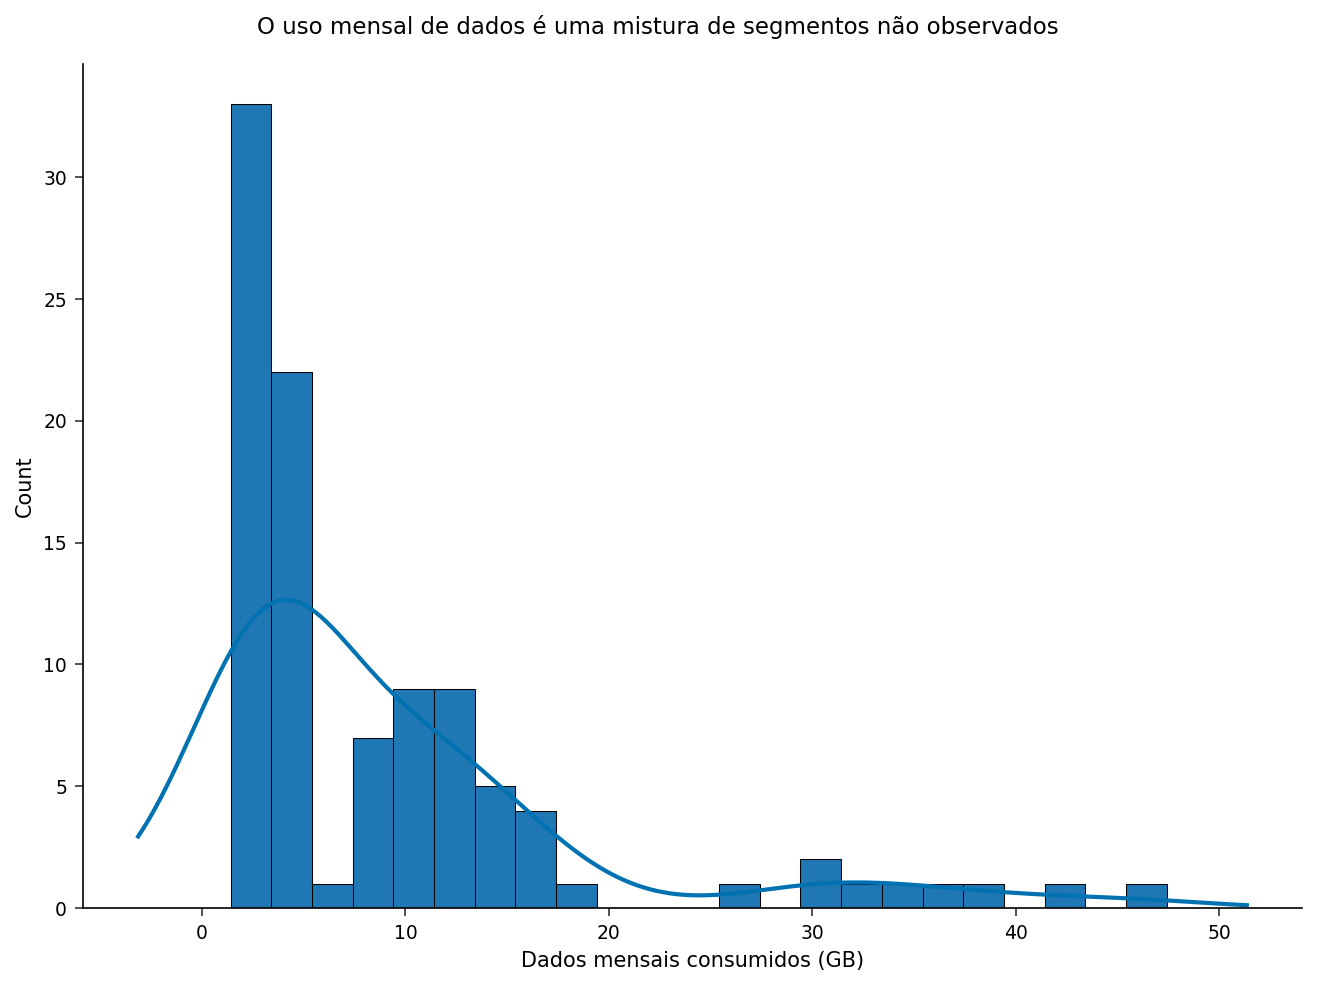

In [3]:
ODS GRAPHICS ON;
PROCEDIMENTO SGPLOT DADOS=subscribers;
   TÍTULO "O uso mensal de dados é uma mistura de segmentos não observados";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS RÓTULO='Dados mensais consumidos (GB)';
EXECUTAR;
TÍTULO;
ODS GRAPHICS OFF;


## Colocando o uso em uma escala comum

O *k*-means particiona pontos pela distância euclidiana, então a escala bruta da variável determina o resultado. Com uma única métrica isso apenas recentraliza o eixo, mas padronizar para média 0 / desvio padrão 1 com o **PROC STANDARD** é o hábito que mantém o fluxo de trabalho correto no momento em que uma segunda métrica de uso (minutos de voz, dias de roaming) é adicionada. Agrupamos na coluna padronizada e reportamos os resultados de volta na escala original em GB.


In [4]:
PROCEDIMENTO STANDARD DADOS=subscribers out=subs_std mean=0 std=1;
   VARIÁVEL data_gb;
EXECUTAR;



NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Particionando assinantes em três segmentos de uso

Guiados pelo conhecimento de domínio sobre os níveis leve / moderado / pesado, pedimos ao **PROC FASTCLUS** por `MAXCLUSTERS=3`. O procedimento inicializa três centros, atribui cada assinante ao mais próximo, recalcula os centros e itera até que as atribuições parem de mudar (`CONVERGE=` com um limite `MAXITER=`). `SEED=` torna a inicialização reproduzível. O conjunto de dados `OUT=` carrega o rótulo `CLUSTER` de cada assinante e sua `DISTANCE` até o centro atribuído; `MEAN=` grava os centroides dos segmentos.

Leia os diagnósticos do procedimento para a qualidade da separação: um **R-Squared** alto (a fração da variância total de uso explicada pelos segmentos) e um **Pseudo F** grande indicam segmentos bem separados e compactos.


In [5]:
PROCEDIMENTO FASTCLUS DADOS=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VARIÁVEL data_gb;
   TÍTULO 'Três segmentos de uso via k-means';
EXECUTAR;
TÍTULO;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Traçando o perfil dos segmentos descobertos

Os rótulos de cluster só são operacionais depois que descrevemos cada segmento em termos de negócio. Combinamos as atribuições de volta ao uso original (não padronizado) e resumimos o tamanho e o consumo típico de cada segmento na escala em GB — os números sobre os quais uma equipe de desenho de planos ou marketing realmente age.


In [6]:
DADOS memberships;
   MESCLAR subscribers
         clusters(MANTER=id CLUSTER distance);
   POR id;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=memberships n mean MIN MAX maxdec=2;
   CLASSE CLUSTER;
   VARIÁVEL data_gb distance;
   RÓTULO CLUSTER="Cluster" distance="Distância ao Centro";
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=memberships(obs=10) noobs RÓTULO;
   VARIÁVEL id data_gb CLUSTER distance segment_true;
   RÓTULO CLUSTER="Cluster" distance="Distância ao Centro";
EXECUTAR;


                                                  The MEANS Procedure

                                   Analysis Variable : data_gb Consumo de Dados (GB)

        Cluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                   Analysis Variable : DISTANCE Distância ao Centro

        Cluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09   


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validando os segmentos recuperados

Como estes são dados sintéticos, reservamos `segment_true`, o rótulo usado para gerar cada assinante. Cruzar o `CLUSTER` recuperado pelo modelo contra o segmento verdadeiro mostra o quão nitidamente a partição separou a população. Forte concentração ao longo de um único mapeamento de cluster para segmento indica uma boa recuperação; a massa fora da diagonal se concentra onde as fronteiras leve/moderado ou moderado/pesado se sobrepõem.


In [7]:
PROCEDIMENTO FREQUÊNCIAS DADOS=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   RÓTULO CLUSTER="Cluster";
EXECUTAR;


                                                   The FREQ Procedure

Table of Cluster by Segmento Real

Cluster |      Leve |  Moderado |    Pesado |      Total
--------+-----------+-----------+-----------+-----------
1       |        54 |         3 |         0 |         57
--------+-----------+-----------+-----------+-----------
2       |         0 |         0 |         9 |          9
--------+-----------+-----------+-----------+-----------
3       |         0 |        33 |         1 |         34
--------+-----------+-----------+-----------+-----------
Total   |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretando os Resultados

- **Centros dos segmentos.** Os três clusters caem quase exatamente sobre os níveis de uso planejados — usuários leves perto de **3 GB**, usuários moderados perto de **13 GB** e usuários pesados perto de **37 GB** — quantificando tanto *onde* cada segmento se situa quanto *quão grande* ele é. O pequeno segmento de usuários pesados, apesar de ser apenas uma fração dos assinantes, é responsável por uma parcela desproporcional do total de dados transportados — o clássico motor das decisões de capacidade de rede e planos premium.
- **Qualidade da separação.** O PROC FASTCLUS reporta um **R-Squared** geral alto e um **Pseudo F** grande, confirmando que os três segmentos são compactos e bem separados, em vez de artefatos de um corte arbitrário. Um único nível deixaria a maior parte dessa variância de uso sem explicação.
- **Sem limites escolhidos manualmente.** A segmentação emerge da geometria da própria distribuição de uso. O procedimento escolheu as fronteiras; nós apenas escolhemos *quantos* níveis pedir, guiados pela forma óbvia de três modos no histograma.
- **Saída acionável.** O conjunto de dados `OUT=` dá a cada assinante um rótulo de segmento *e* uma `DISTANCE` até seu centro. Assinantes distantes de qualquer centro — ou situados entre a fronteira leve/moderado — são exatamente os clientes que vale a pena testar em A/B com ofertas de upsell, enquanto usuários pesados densamente agrupados são candidatos de alta confiança para planos com capacidade dedicada ou ilimitados.

Em resumo, o PROC FASTCLUS converte uma métrica de uso contínua em uma segmentação orientada por dados — sem limites de GB escolhidos manualmente — e a tabulação cruzada contra a verdade reservada confirma que os segmentos são recuperados de forma confiável.
